Implement a ROI Pooling operator. Your code will be given the following variables:

- `input`, a mini-batch of feature maps (a `torch.Tensor` with shape `(n, C, H, W)` and dtype `torch.float32`)
- `boxes`, a list of bounding box coordinates on which you need to perform the ROI Pooling. boxes will be a list of `(L,4)` `torch.Tensor` with `dtype` `torch.float32`, where `boxes[i]` will refer to the `i`-th element of the batch, and contain `L` coordinates in the format `(y1, x1, y2, x2)`
- a tuple of integers `output_size`, containing the number of cells over which pooling is performed, in the format `(heigth, width)`

The code should produce an output `torch.Tensor` out with `dtype` `torch.float32` and shape `(n, L, C, output_size[0], output_size[1])`.

In [1]:
import random
import torch

n = random.randint(1, 3)
C = random.randint(10, 20)
H = random.randint(5, 10)
W = random.randint(5, 10)
oH = random.randint(2, 4)
oW = random.randint(2, 4)
L = random.randint(2, 6)
input = torch.rand(n, C, H, W)
boxes = [torch.zeros(L, 4) for _ in range(n)]
for i in range(n):
  boxes[i][:, 0] = torch.rand(L) * (H-oH)       # y
  boxes[i][:, 1] = torch.rand(L) * (W-oW)       # x
  boxes[i][:, 2] = oH + torch.rand(L) * (H-oH)  # w
  boxes[i][:, 3] = oW + torch.rand(L) * (W-oW)  # h

  boxes[i][:,2:] += boxes[i][:,:2]
  boxes[i][:,2] = torch.clamp(boxes[i][:,2], max=H-1)
  boxes[i][:,3] = torch.clamp(boxes[i][:,3], max=W-1)
output_size = (oH, oW)


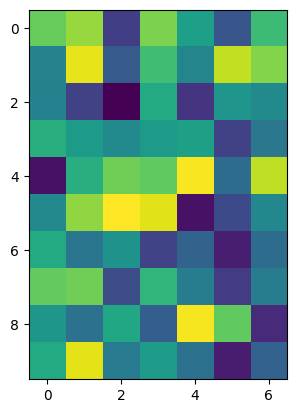

In [2]:
import matplotlib.pyplot as plt

plt.imshow(input[0,0,:,:])

In [4]:
print(boxes)

print(output_size)

[tensor([[0.3493, 0.5368, 9.0000, 3.3161],
        [0.9964, 0.8778, 7.0030, 5.3704]]), tensor([[1.4230, 0.6895, 5.6691, 3.8234],
        [5.7390, 4.2253, 9.0000, 6.0000]]), tensor([[3.1112, 4.7989, 9.0000, 6.0000],
        [4.9826, 0.9160, 9.0000, 6.0000]])]
(4, 2)


In [ ]:
import torch